## Lecture 19: Convolutional Neural Networks

### How do we get a neural network to "see"

![Anniston](../img/L19/L19_fig_1.png)

“Invariant Visual Representation by Single Neurons in the Human Brain" - Quiroga, 2005

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from PIL import Image
from IPython.display import Image as IPImage, display
from tensorflow.keras.datasets import mnist

# ---------------------------
# 1. Load and display the MNIST image
# ---------------------------
(_, _), (x_test, _) = mnist.load_data()
mnist_image_index = np.random.choice(x_test.shape[0], size=1, replace=False)[0]  # shape: (28, 28)
mnist_image = x_test[mnist_image_index]  # Access the image from x_test using the random index


# ---------------------------
# 2. Function to create flash frames (pixel or patch-based)
# ---------------------------
def create_flash_frames(image, patch_size=1):
    """
    Create a list of frames where each frame shows a patch (of size patch_size x patch_size)
    from the original image on a black background.
    """
    frames = []
    height, width = image.shape
    for i in range(0, height, patch_size):
        for j in range(0, width, patch_size):
            frame = np.zeros_like(image)
            frame[i:i+patch_size, j:j+patch_size] = image[i:i+patch_size, j:j+patch_size]
            frames.append(frame)
    return frames

# Create frames for both pixel-level and larger patch (e.g., 4x4) animations
frames_pixel = create_flash_frames(mnist_image, patch_size=1)
frames_patch = create_flash_frames(mnist_image, patch_size=8)

# ---------------------------
# 3. Function to upscale frames using PIL's resize (nearest-neighbor)
# ---------------------------
def upscale_frames(frames, scale_factor=10):
    """
    Upscale each frame by a factor (default 10).
    Nearest neighbor interpolation is used to maintain the pixel art style.
    """
    upscaled = []
    for frame in frames:
        # Convert the numpy array to a PIL Image (convert mode 'L' for grayscale)
        im = Image.fromarray(frame.astype(np.uint8), mode='L')
        # Determine new size based on the scaling factor
        new_size = (im.width * scale_factor, im.height * scale_factor)
        # Resize using nearest-neighbor interpolation
        im_resized = im.resize(new_size, resample=Image.NEAREST)
        # Convert back to a numpy array (if needed by imageio)
        upscaled.append(np.array(im_resized))
    return upscaled

# Upscale the frames for pixel- and patch-level animations
scale_factor = 10  # Adjust this factor to make GIFs larger or smaller
upscaled_frames_pixel = upscale_frames(frames_pixel, scale_factor)
upscaled_frames_patch = upscale_frames(frames_patch, scale_factor)

# ---------------------------
# 4. Save the upscaled frames as animated GIFs
# ---------------------------
pixel_gif_path_up = 'mnist_pixel_flash_upscaled.gif'
patch_gif_path_up = 'mnist_patch_flash_upscaled.gif'

# You can adjust the duration (seconds per frame) to suit your presentation pace.
imageio.mimsave(pixel_gif_path_up, upscaled_frames_pixel, duration=0.08, loop=0)
imageio.mimsave(patch_gif_path_up, upscaled_frames_patch, duration=0.5, loop=0)

# ---------------------------
# 5. Display the upscaled GIF animations inline
# ---------------------------
print("Upscaled Pixel-Level Animation:")
display(IPImage(filename=pixel_gif_path_up))
print("Upscaled Patch-Level Animation (Patch size 4x4):")
display(IPImage(filename=patch_gif_path_up))

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'imageio'

Which of these GIFs do you think makes it easier to see the number?

In [ ]:
import cv2
import numpy as np

def extract_features(image, patch_size=5):
    """
    Extract features for each pixel using RGB values and local neighborhood.

    Args:
        image: RGB image (595, 420, 3)
        patch_size: Size of the local neighborhood patch (must be odd)

    Returns:
        features: Array of shape (n_pixels, n_features) (249900, 78) (595 x 420, 5 x 5 x 3 + 1 x 3)
    """
    height, width, channels = image.shape

    # Add padding to image
    padding = patch_size // 2

    padded = cv2.copyMakeBorder(
        image,
        padding, padding, padding, padding,
        cv2.BORDER_REFLECT
    )

    # TODO: Calculate total number of pixels
    n_pixels = height * width

    # TODO: Calculate total number of features per pixel
    n_features = (patch_size * patch_size * channels) + channels   # 78 features default

    # TODO: Initialize data structue to store features for all pixels
    features = np.zeros((n_pixels, n_features), dtype=np.float32)

    # TODO: Loop through pixels and extracts features for each pixel
    #     hint: the feature vector will be all RGB values for every surrounding pixel concatenated with the pixel itself
    #     hint: this results in a 78 dimensional feature vector, for each pixel!
    #     hint: 5 x 5 patch = 25, 3 colors per pixel gives 3 x 25 = 75 + 3 for the pixel itself again gives 78
    #     hint: use current pixel RGB values and the surrounding local patch
    pixel_idx = 0
    for i in range(padding, padding + height):
        for j in range(padding, padding + width):
            pixel = padded[i, j]
            patch = padded[i-padding:i+padding+1, j-padding:j+padding+1]
            patch_flat = patch.reshape(-1)
            features[pixel_idx] = np.concatenate([pixel, patch_flat])
            pixel_idx += 1

    # Return feature matrix
    return features

Prior to 2020 and the paper “An image is worth 16x16 words” basically all of computer vision was done using: 
```




```
CNNs are still widely used today and were partly an inspiration for transformers

There are a ton of new tasks in computer vision we haven’t seen so far!

These include: Image Classification, Object Detection, Semantic Segmentation, Instance Segmentation, Panoptic Segmentation, Keypoint Detection, Optical Character Recognition (OCR), Image Captioning, Visual Question Answering (VQA), Image-to-Image Translation, Super-Resolution, Image Restoration, 3D Reconstruction, Depth Estimation, Motion Estimation

### Convolutional Neural Network Architecture

![CNN](../img/L19/L19_fig_2.png)

### Learned Representations

![CNN2](../img/L19/L19_fig_3.png)

The first part of a CNN learns a mapping between
```




```

More generally, CNNs are a way of hierarchically applying 
```               

``` 
to (typically) images that let the network recognize certain patterns. The idea comes from a paper about frog neurons which was somewhat replicated in humans!

### Hierarchical Filters

The intuition is that earlier filters learn  
```

```
like edges which then get passed into  
```

```
filters that learn to recognize more complex things like faces from the lower level filters output

![hfilters](../img/L19/L19_fig_4.png)

### Convolution

Technically these are built on a mathematical operation called a “convolution” in which two functions are 
```

```
to create a third function.

Mathematically:
(f * g)(x, y) =

### Filters

A filter is typically a 
```

```
encoding some pattern we’re looking for in an image.

![grid](../img/L19/L19_fig_5.png)

#### Applying Filters to an Image

![grid](../img/L19/L19_fig_6.png)

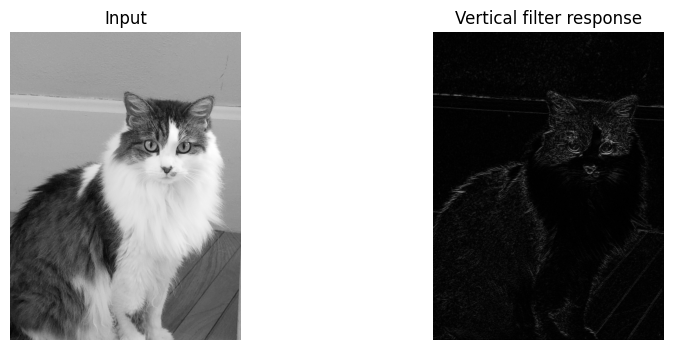

In [ ]:
import numpy as np
from PIL import Image
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

# 1) Load image and convert to grayscale float
img = Image.open("../img/L19/kitty.jpg").convert("L")       # grayscale
I = np.asarray(img, dtype=np.float32) / 255.0

# 2) Define a 3x3 kernel
K = np.array([[1, 1, 1],
              [0, 0, 0],
              [-1, -1, -1]], dtype=np.float32)

# 3) Convolve (same size output)
R = convolve2d(I, K, mode="same", boundary="symm")

# 4) (Optional) visualize result
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Input"); plt.axis("off"); plt.imshow(I, cmap="gray")
plt.subplot(1,2,2); plt.title("Filter response"); plt.axis("off"); plt.imshow(np.abs(R), cmap="gray")
plt.show()

Different kernels will capture different elements of an image!

![kernels](../img/L19/L19_kernel_types.png)

The great thing about CNNs is we don't need to define these kernels manually, they will be learned automatically! Unfortunately what this results in is a loss of interpretability. Below is a set of filters learned on the MNIST data set.

![mfilters](../img/L19/L19_mnist_filters.png)

Epoch 1: 100%|██████████| 938/938 [00:12<00:00, 73.22it/s, loss=0.296]


Test set: Average loss: 0.1705, Accuracy: 9479/10000 (95%)


Epoch 2: 100%|██████████| 938/938 [00:13<00:00, 71.87it/s, loss=0.143] 


Test set: Average loss: 0.1087, Accuracy: 9648/10000 (96%)


Epoch 3: 100%|██████████| 938/938 [00:13<00:00, 70.83it/s, loss=0.208] 


Test set: Average loss: 0.0836, Accuracy: 9740/10000 (97%)


Epoch 4: 100%|██████████| 938/938 [00:12<00:00, 73.40it/s, loss=0.193] 


Test set: Average loss: 0.0699, Accuracy: 9776/10000 (98%)


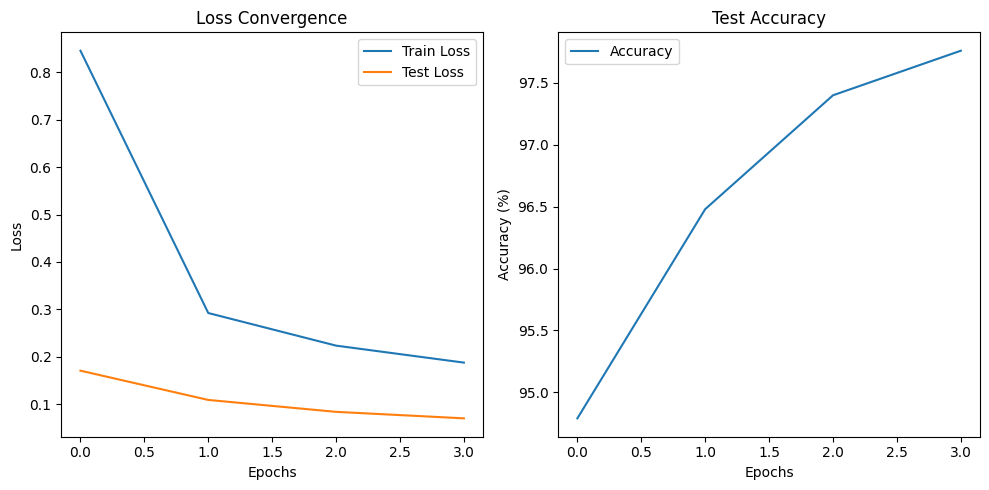

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Define the neural network architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 160)
        self.fc2 = nn.Linear(160, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Data preparation
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./', train=False, download=True, transform=transform),
    batch_size=1000, shuffle=False)

# Initialize network, optimizer and device (GPU)
device = torch.device('cuda' if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
network = Net().to(device)
optimizer = optim.SGD(network.parameters(), lr=0.01, momentum=0.5)

train_losses = []
test_losses = []
accuracies = []

# Training loop with tqdm
def train(epoch):
    network.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for batch_idx, (data, target) in enumerate(progress_bar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = network(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 10 == 0:
            progress_bar.set_postfix(loss=loss.item())

    train_losses.append(running_loss / len(train_loader))

def test():
    network.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = network(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    test_losses.append(test_loss)
    accuracies.append(accuracy)

    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({accuracy:.0f}%)')

# Run training and testing
for epoch in range(1, 5):
    train(epoch)
    test()

# Plotting the loss and accuracy curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()